# Chapter 14: Ethics, Governance, and Responsible AI

## Hands-On Jupyter Notebook

This notebook simulates responsible-AI governance checks with synthetic model cards, policy gates, and escalation signals.

**Time to Complete**: 1-2 hours

---

## Section 1: Setup and Imports

We prepare deterministic governance utilities for policy and ethics auditing.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='talk')

# Configuration
plt.rcParams['figure.figsize'] = (12, 6)
np.random.seed(42)

print('Environment configured for Chapter 14 ethics and governance notebook.')

Environment configured for Chapter 14 ethics and governance notebook.


## Section 2: Load Data and Explore

We create a synthetic model registry with fairness and privacy risk labels.

In [2]:
governance_df = pd.DataFrame([
    {'model_id': 'gov_01', 'use_case': 'triage support', 'fairness_risk': 'medium', 'privacy_risk': 'low', 'approval_state': 'approved'},
    {'model_id': 'gov_02', 'use_case': 'trial matching', 'fairness_risk': 'high', 'privacy_risk': 'medium', 'approval_state': 'conditional'},
    {'model_id': 'gov_03', 'use_case': 'report drafting', 'fairness_risk': 'low', 'privacy_risk': 'low', 'approval_state': 'approved'},
    {'model_id': 'gov_04', 'use_case': 'patient summary', 'fairness_risk': 'medium', 'privacy_risk': 'high', 'approval_state': 'review'},
])
display(governance_df)

,model_id,use_case,fairness_risk,privacy_risk,approval_state
0,gov_01,triage support,medium,low,approved
1,gov_02,trial matching,high,medium,conditional
2,gov_03,report drafting,low,low,approved
3,gov_04,patient summary,medium,high,review


## Section 3: Main Analysis

We compute a simple governance score and escalation flags from policy-relevant fields.

In [3]:
risk_score_map = {'low': 1, 'medium': 2, 'high': 3}
approval_penalty_map = {'approved': 0, 'conditional': 1, 'review': 2}

governance_df['governance_score'] = (
    governance_df['fairness_risk'].map(risk_score_map)
    + governance_df['privacy_risk'].map(risk_score_map)
    + governance_df['approval_state'].map(approval_penalty_map)
)
governance_df['requires_escalation'] = governance_df['governance_score'] >= 6
governance_summary = governance_df.groupby('approval_state', as_index=False).agg(cases=('model_id', 'count'), avg_score=('governance_score', 'mean'))
governance_summary['avg_score'] = governance_summary['avg_score'].round(2)
display(governance_df)
display(governance_summary)

,model_id,use_case,fairness_risk,privacy_risk,approval_state,governance_score,requires_escalation
0,gov_01,triage support,medium,low,approved,3,False
1,gov_02,trial matching,high,medium,conditional,6,True
2,gov_03,report drafting,low,low,approved,2,False
3,gov_04,patient summary,medium,high,review,7,True


,approval_state,cases,avg_score
0,approved,2,2.5
1,conditional,1,6.0
2,review,1,7.0


## Section 4: Visualization

We visualize score patterns and escalation prevalence across use cases.

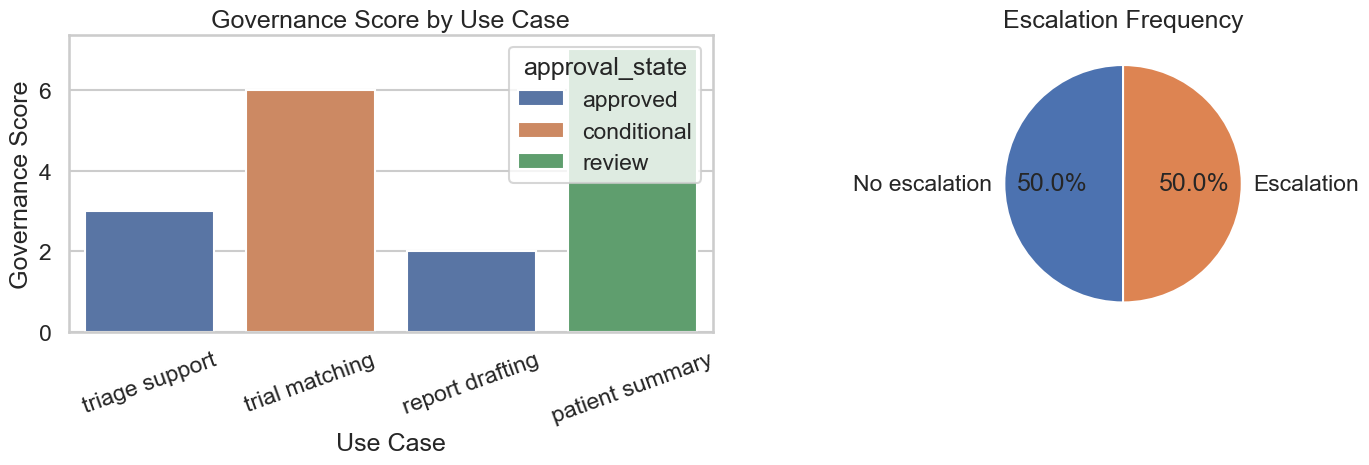

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(data=governance_df, x='use_case', y='governance_score', hue='approval_state', ax=axes[0])
axes[0].set_title('Governance Score by Use Case')
axes[0].set_xlabel('Use Case')
axes[0].set_ylabel('Governance Score')
axes[0].tick_params(axis='x', rotation=20)

escalation_counts = governance_df['requires_escalation'].value_counts()
axes[1].pie(escalation_counts.values, labels=['No escalation', 'Escalation'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Escalation Frequency')

plt.tight_layout()
plt.show()

## Section 5: Exercises

### Exercise 1: Policy Gate

*Description: Flag models that should be blocked from automatic deployment.*

In [5]:
policy_df = governance_df[['model_id', 'use_case', 'governance_score']].copy()
policy_df['blocked'] = policy_df['governance_score'] >= 7
display(policy_df)

,model_id,use_case,governance_score,blocked
0,gov_01,triage support,3,False
1,gov_02,trial matching,6,False
2,gov_03,report drafting,2,False
3,gov_04,patient summary,7,True


### Exercise 2: Bias Review

*Description: Identify models that require enhanced bias monitoring.*

In [6]:
bias_df = governance_df[['model_id', 'fairness_risk', 'privacy_risk', 'approval_state']].copy()
bias_df['bias_watch'] = np.where((bias_df['fairness_risk'] == 'high') | (bias_df['privacy_risk'] == 'high'), 'watch', 'standard')
display(bias_df)

,model_id,fairness_risk,privacy_risk,approval_state,bias_watch
0,gov_01,medium,low,approved,standard
1,gov_02,high,medium,conditional,watch
2,gov_03,low,low,approved,standard
3,gov_04,medium,high,review,watch


## Section 6: Key Takeaways

- Governance benefits from explicit scoring and escalation criteria.
- Ethical review should jointly consider fairness and privacy risk.
- Policy gates make deployment boundaries transparent and auditable.

---

## Next Steps

1. ✅ Complete all exercises
2. 📖 Read Chapter 15 (next chapter)
3. 🔗 Review evaluation and translational chapters as needed
4. 🧪 Extend the governance rubric to your own models

---

**Last Updated**: May 2026